## Procesamiento de imágenes 

### Librerias

In [ ]:
!pip install rasterio
!pip install matplotlib

## Paso 1: Cargar las imágenes para realizar el mosaico 

Poner la ruta de la carpeta donde se encuentren las imágenes de interés en la variable "ruta-carpeta". Este código mostrará automáticamente la información del sensor usado, además de sus respectivas características; sistema de referencia, número de bandas y su respectiva interpretación.

In [1]:
import os
import rasterio
import glob

# =================================================================
# 1. CONFIGURACIÓN: Solo cambia esta ruta a tu carpeta actual
# =================================================================
ruta_carpeta = r'Imagenes Antisana\files\reproyectadas'
# =================================================================

# Buscamos automáticamente todos los .tif
archivos_tif = glob.glob(os.path.join(ruta_carpeta, "*.tif"))

print(f"--- INICIANDO INSPECCIÓN AUTOMÁTICA DE {len(archivos_tif)} ESCENAS ---\n")

for i, ruta in enumerate(archivos_tif, start=1):
    try:
        with rasterio.open(ruta) as src:
            n_bandas = src.count
            
            # NUEVA LÓGICA DE DETECCIÓN ADAPTABLE
            if n_bandas == 8:
                sensor = "PlanetScope (SuperDove)"
            elif n_bandas == 5:
                sensor = "RapidEye"
            elif n_bandas == 4:
                sensor = "PlanetScope (Dove Classic)"
            else:
                sensor = f"Desconocido ({n_bandas} bandas)"

            print(f"ARCHIVO {i}: {os.path.basename(ruta)}")
            print(f"  > Sensor: {sensor}")
            print(f"  > Metadatos: {src.dtypes[0]} | CRS: {src.crs} | Total Bandas: {n_bandas}")
            
            print("  > Interpretación de canales:")
            
            # FIJACIÓN TÉCNICA: Usamos range(n_bandas) para empezar desde 0
            interpretaciones = [src.colorinterp[b] for b in range(n_bandas)]
            
            for idx, interp in enumerate(interpretaciones, start=1):
                # Si el metadato dice 'undefined', le ponemos un nombre genérico
                nombre_canal = interp.name if interp.name != 'undefined' else f"Multiespectral ({idx})"
                print(f"    - Canal {idx}: {nombre_canal}")
            
            print("-" * 60)
            
    except Exception as e:
        print(f"❌ Error procesando {os.path.basename(ruta)}: {e}")

print("\n--- PROCESO DE INSPECCIÓN FINALIZADO ---")

--- INICIANDO INSPECCIÓN AUTOMÁTICA DE 5 ESCENAS ---

ARCHIVO 1: repro_20170716_144949_101a_3B_AnalyticMS_SR_clip.tif
  > Sensor: PlanetScope (Dove Classic)
  > Metadatos: uint16 | CRS: EPSG:32717 | Total Bandas: 4
  > Interpretación de canales:
    - Canal 1: gray
    - Canal 2: Multiespectral (2)
    - Canal 3: Multiespectral (3)
    - Canal 4: Multiespectral (4)
------------------------------------------------------------
ARCHIVO 2: repro_20170716_144950_101a_3B_AnalyticMS_SR_clip.tif
  > Sensor: PlanetScope (Dove Classic)
  > Metadatos: uint16 | CRS: EPSG:32717 | Total Bandas: 4
  > Interpretación de canales:
    - Canal 1: gray
    - Canal 2: Multiespectral (2)
    - Canal 3: Multiespectral (3)
    - Canal 4: Multiespectral (4)
------------------------------------------------------------
ARCHIVO 3: repro_20170716_145104_1034_3B_AnalyticMS_SR_clip.tif
  > Sensor: PlanetScope (Dove Classic)
  > Metadatos: uint16 | CRS: EPSG:32717 | Total Bandas: 4
  > Interpretación de canales:
    

## Reproyección del sistema de referencia

Si sus imágenes presentan un sistema de referencia diferente (CRS), el siguiente código reproyecta las imágenes a EPSG: 32717

In [10]:
import os
import glob
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# 1. RUTAS Y CONFIGURACIÓN
ruta_entrada = r'Satélite RapidEye'
ruta_salida = os.path.join(ruta_entrada, 'reproyectadas')
target_crs = 'EPSG:32717'  # UTM 17S

# Creamos la carpeta de salida si no existe
if not os.path.exists(ruta_salida):
    os.makedirs(ruta_salida)

# Buscamos todos los .tif
archivos = glob.glob(os.path.join(ruta_entrada, "*.tif"))

print(f"--- REPROYECTANDO {len(archivos)} IMÁGENES A {target_crs} ---")

for f in archivos:
    nombre_archivo = os.path.basename(f)
    ruta_final = os.path.join(ruta_salida, f"repro_{nombre_archivo}")
    
    with rasterio.open(f) as src:
        # Calculamos la nueva transformación para que la imagen no se deforme
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds)
        
        # Copiamos y actualizamos los metadatos
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Ejecutamos la reproyección píxel por píxel
        with rasterio.open(ruta_final, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest # Mantenemos los valores originales del sensor
                )
    
    print(f"✅ Procesado: {nombre_archivo} -> Listo en carpeta 'reproyectadas'")

print("\n--- PROCESO FINALIZADO ---")

--- REPROYECTANDO 3 IMÁGENES A EPSG:32717 ---
✅ Procesado: 1739128_2011-11-01_RE2_3A_Analytic_SR_clip.tif -> Listo en carpeta 'reproyectadas'
✅ Procesado: 1839001_2011-11-01_RE2_3A_Analytic_SR_clip.tif -> Listo en carpeta 'reproyectadas'
✅ Procesado: 1839101_2011-11-01_RE2_3A_Analytic_SR_clip.tif -> Listo en carpeta 'reproyectadas'

--- PROCESO FINALIZADO ---


## Creación del mosaico
Poner la rutaa de la carpeta donde se encuentren las imagenes que se utilizarán para realizar el mosaico

--- UNIDENDO 5 ESCENAS ---
✅ Mosaico guardado con éxito como: Mosaico_Antisana_Completo.tif
Mostrando vista previa RGB para sensor: PlanetScope (4b)


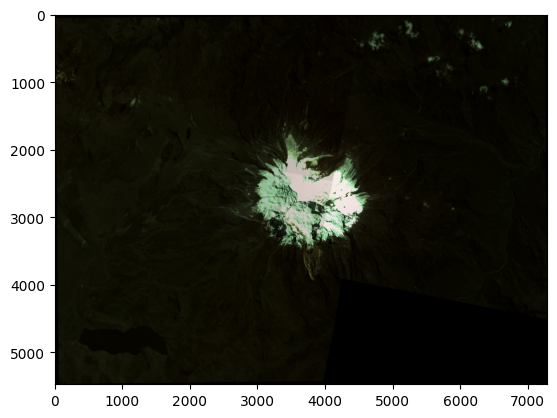

In [1]:
import os
import glob
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import numpy as np

# =================================================================
# 1. CONFIGURACIÓN: Carpeta donde están tus imágenes .tif
# =================================================================
ruta_carpeta = r'Imagenes Antisana\files\reproyectadas'
# =================================================================

# 2. Búsqueda automática de archivos
archivos_tif = glob.glob(os.path.join(ruta_carpeta, "*.tif"))
datasets = [rasterio.open(f) for f in archivos_tif]

print(f"--- UNIDENDO {len(datasets)} ESCENAS ---")

# 3. Fusión de imágenes (Merge)
mosaic, out_trans = merge(datasets)

# 4. GUARDADO DEL MOSAICO EN DISCO
out_meta = datasets[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "crs": datasets[0].crs
})

nombre_mosaico = "Mosaico_Antisana_Completo.tif"
with rasterio.open(nombre_mosaico, "w", **out_meta) as dest:
    dest.write(mosaic)

print(f"✅ Mosaico guardado con éxito como: {nombre_mosaico}")

# =================================================================
# 5. VISUALIZACIÓN ADAPTABLE (Actualizada para 4 Bandas)
# =================================================================
def normalize(array):
    """Función para que la imagen no se vea negra al mostrarla"""
    # Usamos nanmin y nanmax de manera preventiva por si existen bordes vacíos
    array_min, array_max = np.nanmin(array), np.nanmax(array)
    if array_max - array_min == 0: return array
    return (array - array_min) / (array_max - array_min)

# Detectamos el número de bandas del dataset actual
n_bandas = datasets[0].count

# Selección dinámica de canales RGB según el sensor detectado
if n_bandas == 8:
    # PlanetScope SuperDove: Rojo=B6 (idx 5), Verde=B4 (idx 3), Azul=B2 (idx 1)
    rgb_mosaic = np.stack([normalize(mosaic[5]), normalize(mosaic[3]), normalize(mosaic[1])])
    sensor_txt = "PlanetScope (8b)"
elif n_bandas == 4:
    # PlanetScope Dove Classic: Rojo=B3 (idx 2), Verde=B2 (idx 1), Azul=B1 (idx 0)
    rgb_mosaic = np.stack([normalize(mosaic[2]), normalize(mosaic[1]), normalize(mosaic[0])])
    sensor_txt = "PlanetScope (4b)"
else:
    # RapidEye o fallback genérico: Rojo=B3 (idx 2), Verde=B2 (idx 1), Azul=B1 (idx 0)
    rgb_mosaic = np.stack([normalize(mosaic[2]), normalize(mosaic[1]), normalize(mosaic[0])])
    sensor_txt = "RapidEye (5b)"

print(f"Mostrando vista previa RGB para sensor: {sensor_txt}")
show(rgb_mosaic)

# Cerramos los archivos abiertos para liberar memoria RAM
for ds in datasets: ds.close()

## Cortar el mosaico en un AOI
Este código recorta el mosaico en un área de interés. Inserte la ruta del AOI en formato Geojson

In [14]:
import fiona
import rasterio
import rasterio.mask
from fiona.transform import transform_geom

# 1. CONFIGURACIÓN DE RUTAS
# Asegúrate de que el nombre del GeoJSON coincida con el tuyo
ruta_mosaico = 'Carihuairazo_Mosaico_Completo.tif'
ruta_aoi = r'Satelite_Planet\Carihuairzo_26_08_2023_psscene_analytic_8b_sr_udm2_Jonathan\Cari_aoi.geojson'

# 2. CARGAR Y TRANSFORMAR EL AOI
with rasterio.open(ruta_mosaico) as src:
    raster_crs = src.crs
    
    with fiona.open(ruta_aoi, "r") as g:
        # Extraemos la geometría y la transformamos al CRS del satélite automáticamente
        geoms = [feature["geometry"] for feature in g]
        aoi_transformado = [transform_geom(g.crs, raster_crs, geom) for geom in geoms]

    # 3. APLICAR EL RECORTE (MASK)
    # crop=True elimina todo lo que está fuera del polígono
    out_image, out_transform = rasterio.mask.mask(src, aoi_transformado, crop=True)
    out_meta = src.meta.copy()

    # 4. ACTUALIZAR METADATOS
    # El recorte cambia el tamaño y la posición (transform) de la imagen
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    # 5. GUARDAR EL RESULTADO FINAL
    nombre_recorte = "FINAL_RECORTADO.tif"
    with rasterio.open(nombre_recorte, "w", **out_meta) as dest:
        dest.write(out_image)

print(f"--- PROCESO COMPLETADO ---")
print(f"✅ Imagen recortada guardada como: {nombre_recorte}")
print(f"Dimensiones finales: {out_image.shape[2]}x{out_image.shape[1]} píxeles")

ModuleNotFoundError: No module named 'fiona'

## Normalización TOA
Insertar la ruta de los metadatos de las imágenes en la variable "ruta_xml" 

In [3]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import rasterio

# =================================================================
# 1. CONFIGURACIÓN
# =================================================================
archivo_mosaico = "Mosaico_Antisana_Completo.tif"
# Recuerda apuntar esta ruta al archivo XML de metadatos de tu carpeta actual
ruta_xml = r'Imagenes Antisana\files\20170716_145105_1034_3B_AnalyticMS_metadata_clip.xml'

def extraer_coeficientes_universal(xml_path):
    if not os.path.exists(xml_path):
        return None
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    coeffs = {}
    current_band = None
    
    for elem in root.iter():
        tag = elem.tag.split('}')[-1] # Limpiamos el namespace
        
        # 1. Identificamos el número de banda
        if tag == 'bandNumber':
            current_band = int(elem.text)
            
        # 2. Buscamos el coeficiente (probamos los dos nombres conocidos)
        elif tag in ['reflectanceCoefficient', 'radiometricScaleFactor'] and current_band is not None:
            coeffs[current_band] = float(elem.text)
            
    return coeffs

# =================================================================
# 2. PROCESAMIENTO Y CALIBRACIÓN
# =================================================================
with rasterio.open(archivo_mosaico) as src:
    n_bandas = src.count
    
    # SELECCIÓN DINÁMICA DE ÍNDICES SEGÚN EL SENSOR DETECTADO
    if n_bandas == 8:
        # PlanetScope SuperDove
        idx_red, idx_nir = 6, 8
        sensor = "PlanetScope (8b)"
    elif n_bandas == 4:
        # PlanetScope Dove Classic: Rojo es Banda 3, NIR es Banda 4
        idx_red, idx_nir = 3, 4
        sensor = "PlanetScope (4b)"
    else:
        # RapidEye
        idx_red, idx_nir = 3, 5
        sensor = "RapidEye (5b)"

    print(f"--- Sensor detectado: {sensor} ---")
    
    all_coeffs = extraer_coeficientes_universal(ruta_xml)
    
    if all_coeffs and idx_red in all_coeffs and idx_nir in all_coeffs:
        # Carga de bandas
        band_red = src.read(idx_red).astype('float32')
        band_nir = src.read(idx_nir).astype('float32')
        
        # Aplicación de los factores encontrados
        c_red = all_coeffs[idx_red]
        c_nir = all_coeffs[idx_nir]
        
        band_red_toa = band_red * c_red
        band_nir_toa = band_nir * c_nir
        
        print(f"✅ ¡Calibración exitosa!")
        print(f"   Bandas encontradas en XML: {list(all_coeffs.keys())}")
        print(f"   Factor Rojo (B{idx_red}): {c_red}")
        print(f"   Factor NIR (B{idx_nir}): {c_nir}")
    else:
        print("❌ ERROR: No se encontraron los coeficientes necesarios.")
        if all_coeffs: 
            print(f"   El XML solo tiene estas bandas: {list(all_coeffs.keys())}")

--- Sensor detectado: PlanetScope (4b) ---
✅ ¡Calibración exitosa!
   Bandas encontradas en XML: [1, 2, 3, 4]
   Factor Rojo (B3): 2.6685371439e-05
   Factor NIR (B4): 4.01634057214e-05


## Cálculo matemático para NDVI

In [8]:
import numpy as np
import rasterio

# =================================================================
# 1. CÁLCULO DEL NDVI (Usando valores TOA normalizados)
# =================================================================
# Hereda automáticamente 'sensor', 'band_nir_toa' y 'band_red_toa' de la celda de calibración
print(f"Calculando NDVI para {sensor}...")

# Ignoramos advertencias de división por cero (áreas de sombra o bordes sin datos)
np.seterr(divide='ignore', invalid='ignore')

# Aplicamos la fórmula estándar: (NIR - Rojo) / (NIR + Rojo)
# Nota: Al venir ya como float32 del paso previo, la operación matricial es directa y rápida
ndvi = (band_nir_toa - band_red_toa) / (band_nir_toa + band_red_toa)

# Verificación de rangos analíticos (Debe estar contenido entre -1 y 1)
print(f"Rango de NDVI detectado para el reporte: ({np.nanmin(ndvi):.4f}, {np.nanmax(ndvi):.4f})")

# =================================================================
# 2. CONFIGURACIÓN DEL ARCHIVO DE SALIDA (GeoTIFF)
# =================================================================
archivo_original = "Mosaico_Antisana_Completo.tif"

# MEJORA: Hacemos el nombre dinámico para que los resultados de Planet (4b), 
# Planet (8b) y RapidEye se guarden por separado y no se borren entre sí.
sensor_limpio = sensor.replace(" ", "_").replace("(", "").replace(")", "")
nombre_salida = f"NDVI_{sensor_limpio}_Final_Calibrado.tif"

with rasterio.open(archivo_original) as src:
    # Copiamos la georreferenciación, tamaño y sistema de coordenadas (CRS)
    kwargs = src.meta.copy()

# FIJACIÓN TÉCNICA: En rasterio, el tipo de dato ráster se pasa como string ('float32').
# Usar 'rasterio.float32' causa un AttributeError en la librería.
kwargs.update(
    dtype='float32',  
    count=1,
    driver='GTiff',
    nodata=np.nan     # Definimos formalmente que las zonas vacías se traten como NaN
)

# =================================================================
# 3. GUARDADO DEL MAPA EN DISCO
# =================================================================
with rasterio.open(nombre_salica := nombre_salida, 'w', **kwargs) as dst:
    # Escribimos la matriz final en la banda 1
    dst.write(ndvi.astype('float32'), 1)

print(f"\n--- PROCESO COMPLETADO ---")
print(f"✅ ¡Éxito! Se ha generado el archivo GeoTIFF indexado: {nombre_salida}")

Calculando NDVI para PlanetScope (4b)...
Rango de NDVI detectado para el reporte: (-0.1583, 0.9297)

--- PROCESO COMPLETADO ---
✅ ¡Éxito! Se ha generado el archivo GeoTIFF indexado: NDVI_PlanetScope_4b_Final_Calibrado.tif


## Visualización de la imágen NDVI

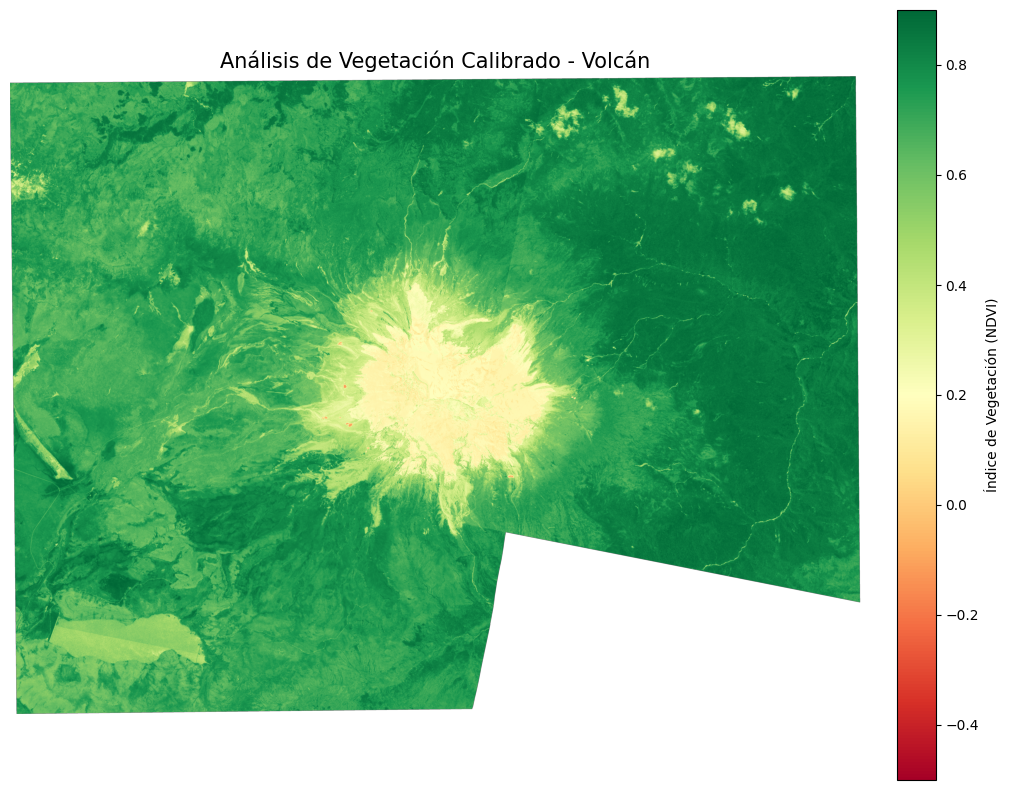

✅ Visualización generada con éxito.
Rango de valores en la imagen: -0.16 a 0.93


In [9]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargamos el archivo que acabamos de crear
archivo_ndvi = 'NDVI_PlanetScope_4b_Final_Calibrado.tif'  # Cambia el nombre según tu sensor

try:
    with rasterio.open(archivo_ndvi) as src:
        ndvi_map = src.read(1)
        
        # 2. Configuración de la figura
        plt.figure(figsize=(12, 10))
        
        # 3. Graficamos con la paleta RdYlGn (Red-Yellow-Green)
        # vmin y vmax limitan la escala al rango real del NDVI (-1 a 1)
        # Ajustamos vmin a -0.5 para que el glaciar resalte en tonos rojizos/naranjas
        im = plt.imshow(ndvi_map, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
        
        # 4. Detalles estéticos
        plt.colorbar(im, label='Índice de Vegetación (NDVI)', fraction=0.046, pad=0.04)
        plt.title('Análisis de Vegetación Calibrado - Volcán', fontsize=15)
        plt.axis('off') # Quitamos las coordenadas de los píxeles para que se vea más limpio
        
        plt.show()
        
        print(f"✅ Visualización generada con éxito.")
        print(f"Rango de valores en la imagen: {np.nanmin(ndvi_map):.2f} a {np.nanmax(ndvi_map):.2f}")

except Exception as e:
    print(f"❌ Error al visualizar: {e}")
    print("Asegúrate de haber instalado matplotlib (!pip install matplotlib)")

 ## Histrograma del NDVI

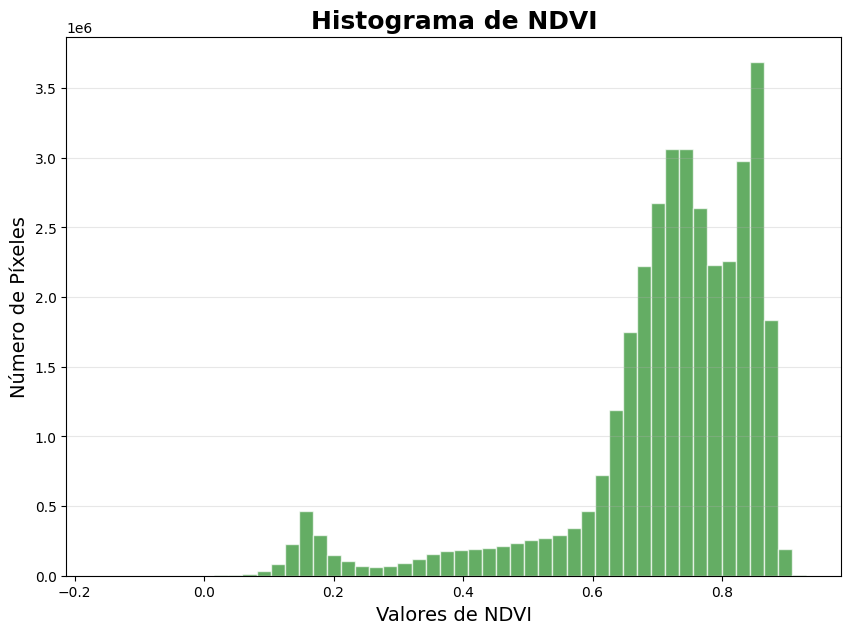

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos: eliminamos los valores NaN para que no den error en el gráfico
# ndvi.flatten() convierte la matriz 2D en una sola lista de números
x = ndvi[~np.isnan(ndvi)]

# 2. Configurar el gráfico
fig2 = plt.figure(figsize=(10,7))
ax = fig2.add_subplot(111)

plt.title("Histograma de NDVI", fontsize=18, fontweight='bold')
plt.xlabel("Valores de NDVI", fontsize=14)
plt.ylabel("Número de Píxeles", fontsize=14)

# 3. Crear el histograma
# 'bins' define cuántas barras tendrá el gráfico. 50-100 suele dar buena resolución.
numBins = 50
ax.hist(x, numBins, color='forestgreen', alpha=0.7, edgecolor='white')

# Añadir una rejilla para mejor lectura
plt.grid(axis='y', alpha=0.3)

# 4. Guardar el histograma (Quitamos 'output/' para evitar errores de carpeta)
fig2.savefig("NDVI_Histograma.png", dpi=200, bbox_inches='tight', pad_inches=0.7)

plt.show()

 ## Carga de bandas para cálculo de NDSI

In [11]:
import rasterio
import numpy as np

# 1. Configuración del archivo
archivo_mosaico = "Mosaico_Antisana_Completo.tif"  # Asegúrate de que este nombre coincida con el mosaico que has creado

# 2. Apertura e identificación dinámica del sensor
with rasterio.open(archivo_mosaico) as src:
    n_bandas = src.count
    crs_actual = src.crs
    
    # Lógica de selección de bandas según el sensor
    if n_bandas == 8:
        # PlanetScope SuperDove
        idx_green, idx_nir = 4, 8
        sensor = "PlanetScope (8b)"
    elif n_bandas == 5:
        # RapidEye
        idx_green, idx_nir = 2, 5
        sensor = "RapidEye (5b)"
    else:
        # Fallback genérico (ej. PlanetScope 4 bandas)
        idx_green, idx_nir = 2, 4
        sensor = f"Desconocido ({n_bandas} bandas)"

    print(f"--- PROCESANDO: {sensor} ---")
    print(f"Sistema de Coordenadas: {crs_actual}")
    
    # Carga de bandas con conversión a float32 para el cálculo matemático
    band_green = src.read(idx_green).astype('float32')
    band_nir = src.read(idx_nir).astype('float32')

print(f"\n✅ Bandas listas para NDSI:")
print(f"   - Verde (Banda {idx_green}) cargada.")
print(f"   - NIR   (Banda {idx_nir}) cargada.")

--- PROCESANDO: Desconocido (4 bandas) ---
Sistema de Coordenadas: EPSG:32717

✅ Bandas listas para NDSI:
   - Verde (Banda 2) cargada.
   - NIR   (Banda 4) cargada.


## Normalización TOA 

In [12]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import rasterio

# =================================================================
# 1. CONFIGURACIÓN
# =================================================================
archivo_mosaico = "Mosaico_Antisana_Completo.tif"
# Recuerda apuntar esta ruta al archivo XML de metadatos de tu carpeta actual
ruta_xml = r'Imagenes Antisana\files\20170716_145105_1034_3B_AnalyticMS_metadata_clip.xml'

def extraer_coeficientes_universal(xml_path):
    if not os.path.exists(xml_path):
        return None
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    coeffs = {}
    current_band = None
    
    for elem in root.iter():
        tag = elem.tag.split('}')[-1] # Limpiamos el namespace
        
        # 1. Identificamos el número de banda
        if tag == 'bandNumber':
            current_band = int(elem.text)
            
        # 2. Buscamos el coeficiente (probamos los dos nombres conocidos)
        elif tag in ['reflectanceCoefficient', 'radiometricScaleFactor'] and current_band is not None:
            coeffs[current_band] = float(elem.text)
            
    return coeffs

# =================================================================
# 2. PROCESAMIENTO Y CALIBRACIÓN
# =================================================================
with rasterio.open(archivo_mosaico) as src:
    n_bandas = src.count
    
    # SELECCIÓN DINÁMICA DE ÍNDICES SEGÚN EL SENSOR DETECTADO
    if n_bandas == 8:
        # PlanetScope SuperDove
        idx_red, idx_nir = 6, 8
        sensor = "PlanetScope (8b)"
    elif n_bandas == 4:
        # PlanetScope Dove Classic: Rojo es Banda 3, NIR es Banda 4
        idx_red, idx_nir = 3, 4
        sensor = "PlanetScope (4b)"
    else:
        # RapidEye
        idx_red, idx_nir = 3, 5
        sensor = "RapidEye (5b)"

    print(f"--- Sensor detectado: {sensor} ---")
    
    all_coeffs = extraer_coeficientes_universal(ruta_xml)
    
    if all_coeffs and idx_red in all_coeffs and idx_nir in all_coeffs:
        # Carga de bandas
        band_red = src.read(idx_red).astype('float32')
        band_nir = src.read(idx_nir).astype('float32')
        
        # Aplicación de los factores encontrados
        c_red = all_coeffs[idx_red]
        c_nir = all_coeffs[idx_nir]
        
        band_red_toa = band_red * c_red
        band_nir_toa = band_nir * c_nir
        
        print(f"✅ ¡Calibración exitosa!")
        print(f"   Bandas encontradas en XML: {list(all_coeffs.keys())}")
        print(f"   Factor Rojo (B{idx_red}): {c_red}")
        print(f"   Factor NIR (B{idx_nir}): {c_nir}")
    else:
        print("❌ ERROR: No se encontraron los coeficientes necesarios.")
        if all_coeffs: 
            print(f"   El XML solo tiene estas bandas: {list(all_coeffs.keys())}")

--- Sensor detectado: PlanetScope (4b) ---
✅ ¡Calibración exitosa!
   Bandas encontradas en XML: [1, 2, 3, 4]
   Factor Rojo (B3): 2.6685371439e-05
   Factor NIR (B4): 4.01634057214e-05


## Cálculo matemático para NDSI

In [13]:
# 1. Ignorar advertencias de división por cero (áreas sin datos)
np.seterr(divide='ignore', invalid='ignore')

# 2. Cálculo del NDSI 
# La fórmula es (Verde - NIR) / (Verde + NIR)
ndsi = (band_green - band_nir) / (band_green + band_nir)

# 3. Verificación de rangos
print(f"--- Cálculo de NDSI finalizado para {sensor} ---")
print(f"Valor mínimo detectado: {np.nanmin(ndsi):.4f}")
print(f"Valor máximo detectado: {np.nanmax(ndsi):.4f}")

--- Cálculo de NDSI finalizado para PlanetScope (4b) ---
Valor mínimo detectado: -0.9985
Valor máximo detectado: 0.3455


## Visualización NDSI

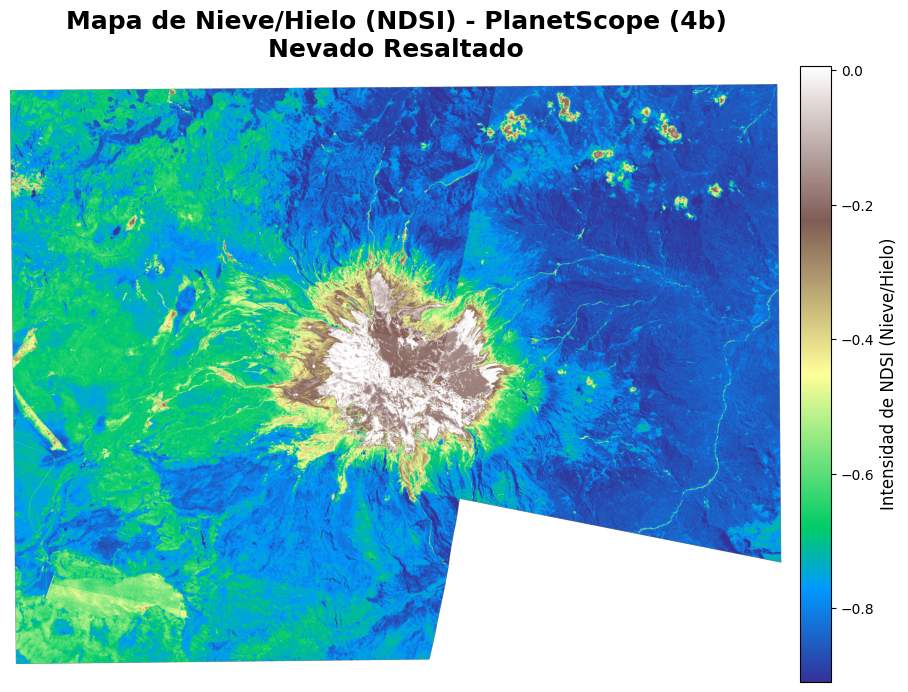

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

# 1. Definimos los límites basados en la distribución real de la nieve
# Usamos un percentil alto (98%) para asegurar que la cima del glaciar sea el máximo
vmin_ndsi = np.nanpercentile(ndsi, 2)   # El suelo más oscuro
vmax_ndsi = np.nanpercentile(ndsi, 99)  # El punto más brillante de nieve

# 2. CREAR LA FIGURA
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111)

# Usamos el mapa de color 'terrain' o 'gist_earth' que se parece mucho a tu ejemplo
# Estas paletas pasan de azul (agua/sombras) a verde (suelo) y blanco (nieve)
cmap_nieve = plt.cm.terrain 

# Ajustamos la normalización para que el blanco aparezca solo en los valores más altos
norm_nieve = colors.Normalize(vmin=vmin_ndsi, vmax=vmax_ndsi)

cax = ax.imshow(ndsi, cmap=cmap_nieve, norm=norm_nieve)

# 3. ESTÉTICA
ax.axis('off')
ax.set_title(f'Mapa de Nieve/Hielo (NDSI) - {sensor}\nNevado Resaltado', 
             fontsize=18, fontweight='bold', pad=20)

# 4. LEYENDA (Colorbar)
cbar = fig.colorbar(cax, orientation='vertical', shrink=0.8, pad=0.02)
cbar.set_label('Intensidad de NDSI (Nieve/Hielo)', fontsize=12)

plt.show()

# Guardar la versión final
plt.savefig(f'NDSI_{sensor.replace(" ", "_")}_PRO.png', dpi=300, bbox_inches='tight')

##

## Ajuste para mejorar la visualización de la nieve

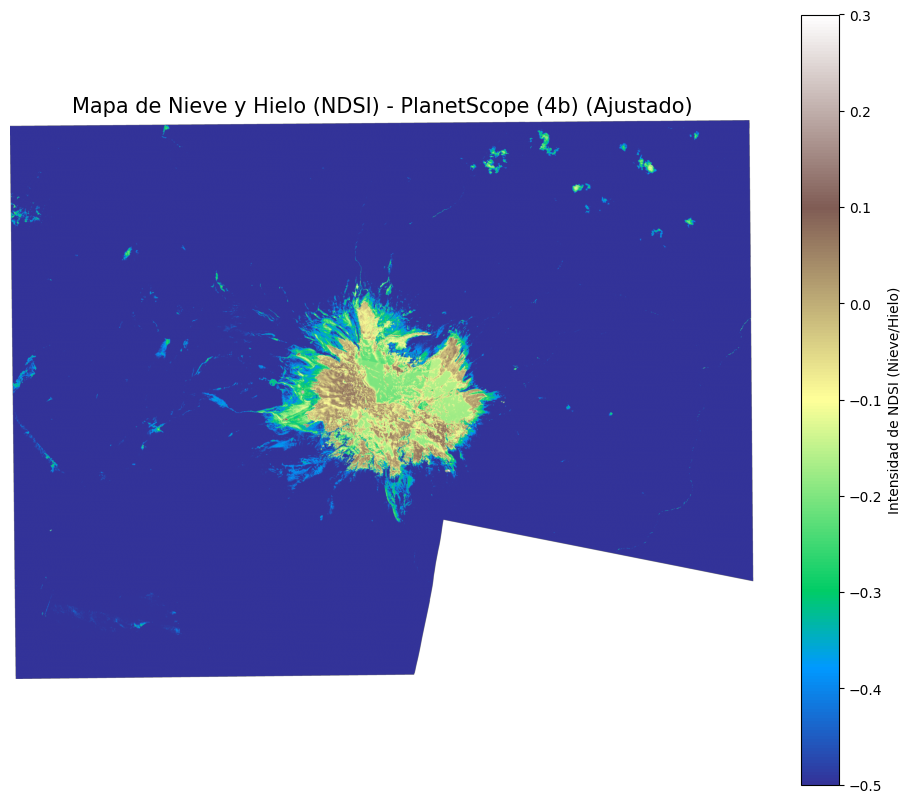

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Aplicamos los límites al arreglo ndsi usando np.clip()
ndsi_acotado = np.clip(ndsi, a_min=-0.5, a_max=0.3)

# 2. Mostramos el resultado
plt.figure(figsize=(12, 10))

# Visualizamos el NDSI con los nuevos límites
plt.imshow(ndsi_acotado, cmap='terrain', vmin=-0.5, vmax=0.3)

plt.colorbar(label='Intensidad de NDSI (Nieve/Hielo)')
plt.title(f'Mapa de Nieve y Hielo (NDSI) - {sensor} (Ajustado)', fontsize=15)
ax = plt.gca()
ax.axis('off')
plt.show()